# TEST CODE 

See
https://github.com/bouz1/PypiContributions/blob/main/emi-receiver/app/emi_receiver/test/test_CISPR_16_1_1.py


```python 
import numpy as np
import pandas as pd
import scipy.signal
import scipy.fft
from numba import jit




from app.emi_receiver.src.emi_receiver import receiver


        




def generate_pulse_train(fs, duration, prf, amplitude_volts=1.0, pulse_width_samples=1):
    """
    Generates a train of rectangular pulses (Dirac-like).
    """
    n_samples = int(fs * duration)
    t = np.arange(n_samples) / fs
    signal = np.zeros(n_samples)
    
    # Calculate spacing in samples
    period_samples = int(fs / prf)
    
    # Create pulses
    # We use a simple loop or slice assignment for speed
    indices = np.arange(0, n_samples, period_samples)
    
    # Make the pulse slightly wider than 1 sample to avoid aliasing artifacts 
    # but still essentially an impulse for 30MHz bandwidth.
    for idx in indices:
        if idx + pulse_width_samples < n_samples:
            signal[idx : idx + pulse_width_samples] = amplitude_volts
            
    return signal

#def run_cispr16_validation():
def test_cispr16_validation():
    print("\n" + "="*60)
    print("STARTING CISPR 16-1-1 VALIDATION (BAND B)")
    print("Test: Quasi-Peak Response to Pulse Repetition Frequency")
    print("="*60)
    
    # Configuration
    Fs = 100e6         # 100 MS/s
    Rbw = 9000         # 9 kHz
    Freq_Interest = 150e3 # We will check the level at 150 kHz (Start of Band B)
    
    # CISPR 16-1-1 Limits (Relative to 100 Hz)
    # PRF : Expected Delta (dB)
    cispr_targets = {
        100: 0.0,
        60: -1.4,
        20: -5.9,
        10: -10.5,
        2:  -20.5,
        1:  -23.5
    }
    
    results = {}
    ref_level = None
    
    # ---------------------------------------------------------
    # Loop through PRFs
    # ---------------------------------------------------------
    for prf, expected_delta in cispr_targets.items():
        print(f"Testing PRF: {prf:3d} Hz...", end="")
        
        # 1. Generate Signal
        # We need enough time for the QP detector (Tau=160ms) to stabilize.
        # For 1Hz, we need at least 2-3 seconds.
        # For 100Hz, 0.5 seconds is enough.
        if prf < 10:
            duration = 2.5 
        else:
            duration = 0.5
            
        sig = generate_pulse_train(Fs, duration, prf, amplitude_volts=0.5, pulse_width_samples=5)
        
        # 2. Run Receiver
        # We use a larger step (50kHz) to speed up the validation, 
        # because we only care about the amplitude at low frequencies, not the resolution.
        freqs, peak, avg, qp = receiver(sig, Fs, rbw=9000, step=50000, band='B')
        
        # 3. Measure Level at Frequency of Interest (e.g., closest to 150kHz)
        idx = np.argmin(np.abs(freqs - Freq_Interest))
        measured_qp = qp[idx]
        
        results[prf] = measured_qp
        print(f" QP Level = {measured_qp:.2f} dBµV")

    # ---------------------------------------------------------
    # Calculate Deltas and Check Pass/Fail
    # ---------------------------------------------------------
    print("\n" + "-"*60)
    print(f"{'PRF (Hz)':<10} | {'Target (dB)':<12} | {'Actual (dB)':<12} | {'Error (dB)':<10} | {'Status'}")
    print("-"*60)
    
    ref_level = results[100]
    
    all_passed = True
    
    for prf, expected_delta in cispr_targets.items():
        measured_val = results[prf]
        actual_delta = measured_val - ref_level
        
        error = abs(actual_delta - expected_delta)
        
        # Tolerance usually +/- 1.5 dB
        tolerance = 2.0 if prf <= 2 else 1.5
        passed = error <= tolerance
        
        if not passed: all_passed = False
        
        status = "PASS" if passed else "FAIL"
        
        print(f"{prf:<10} | {expected_delta:<12.1f} | {actual_delta:<12.2f} | {error:<10.2f} | {status}")
        
    print("-"*60)
    if all_passed:
        print("RESULT: VALIDATION SUCCESSFUL. Receiver complies with CISPR 16-1-1 Pulse Response.")
    else:
        print("RESULT: VALIDATION FAILED. Check detector time constants or overlaps.")

# Run the test
if __name__ == "__main__":
    #run_cispr16_validation()
    test_cispr16_validation()
```



# UNDERSTUND THE CODE

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def generate_pulse_train(fs, duration, prf, amplitude_volts=1.0, pulse_width_samples=1):
    """
    Generates a train of rectangular pulses (Dirac-like).
    """
    n_samples = int(fs * duration)
    t = np.arange(n_samples) / fs
    signal = np.zeros(n_samples)
    
    # Calculate spacing in samples
    period_samples = int(fs / prf)
    
    # Create pulses
    # We use a simple loop or slice assignment for speed
    indices = np.arange(0, n_samples, period_samples)
    
    # Make the pulse slightly wider than 1 sample to avoid aliasing artifacts 
    # but still essentially an impulse for 30MHz bandwidth.
    for idx in indices:
        if idx + pulse_width_samples < n_samples:
            signal[idx : idx + pulse_width_samples] = amplitude_volts
            
    return signal

In [5]:
Fs = 100e6         # 100 MS/s
# CISPR 16-1-1 Limits (Relative to 100 Hz)
# PRF : Expected Delta (dB)
cispr_targets = {
    100: 0.0,
    60: -1.4,
    20: -5.9,
    10: -10.5,
    2:  -20.5,
    1:  -23.5
}

results = {}
ref_level = None

# ---------------------------------------------------------
# Loop through PRFs
# ---------------------------------------------------------
for prf, expected_delta in cispr_targets.items():
    print(f"Testing PRF: {prf:3d} Hz...", end="")
    
    # 1. Generate Signal
    # We need enough time for the QP detector (Tau=160ms) to stabilize.
    # For 1Hz, we need at least 2-3 seconds.
    # For 100Hz, 0.5 seconds is enough.
    if prf < 10:
        duration = 2.5 
    else:
        duration = 0.5
        
    sig = generate_pulse_train(Fs, duration, prf, amplitude_volts=0.5, pulse_width_samples=5)
    break

Testing PRF: 100 Hz...

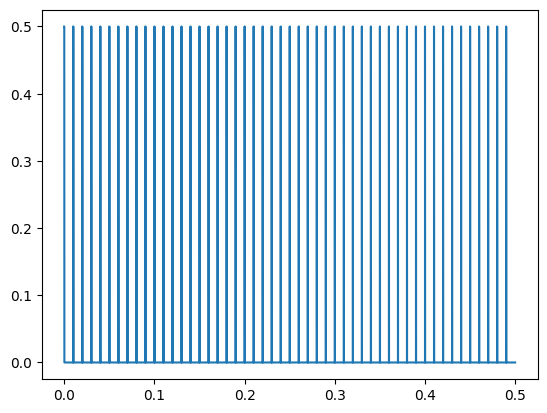

In [6]:
t = np.arange(0, len(sig)/Fs, 1/Fs)
plt.plot(t, sig)

Pulse duration  50.0 ns


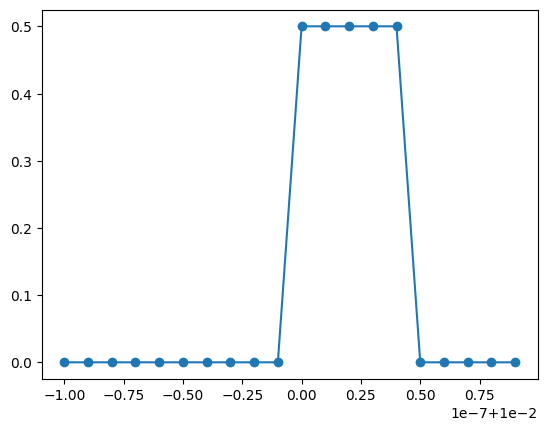

In [7]:
k= np.where(sig>0.2)[0][5:][0]
plt.plot(t[k-10:k+10], sig[k-10:k+10], marker ="o")


print("Pulse duration ", 1e9*5/Fs, "ns")